In [11]:
from pathlib import Path
import sys
import pdb
import numpy as np
from mlx_embeddings.utils import load
from sklearn.decomposition import PCA

In [8]:
base_file_dir = Path('data/docs')

def load_embeds(base_dir):
    embeds = {}
    for p in base_dir.glob('*.npz'):
        name = p.stem
        arr = np.load(p)
        embeds[name] = arr['embeds']
    return embeds

embeds = load_embeds(base_file_dir)

In [ ]:
nametoidx = {n: i for i, n in enumerate(embeds.keys())}
idxtoname = {i: n for n, i in nametoidx.items()}

def get_embed_matrix(embeds, idxtoname):
    n = len(idxtoname)
    d = next(iter(embeds.values())).shape[1]
    matrix = np.zeros((n, d))
    for i in range(n):
        name = idxtoname[i]
        matrix[i, :] = embeds[name]
    return matrix


In [12]:
embed_matrix = get_embed_matrix(embeds, idxtoname)

In [36]:

def get_embedding_pca(embed_matrix, n_components=2):
    pca = PCA(n_components=n_components)
    reduced = pca.fit_transform(embed_matrix)
    return reduced, pca.components_

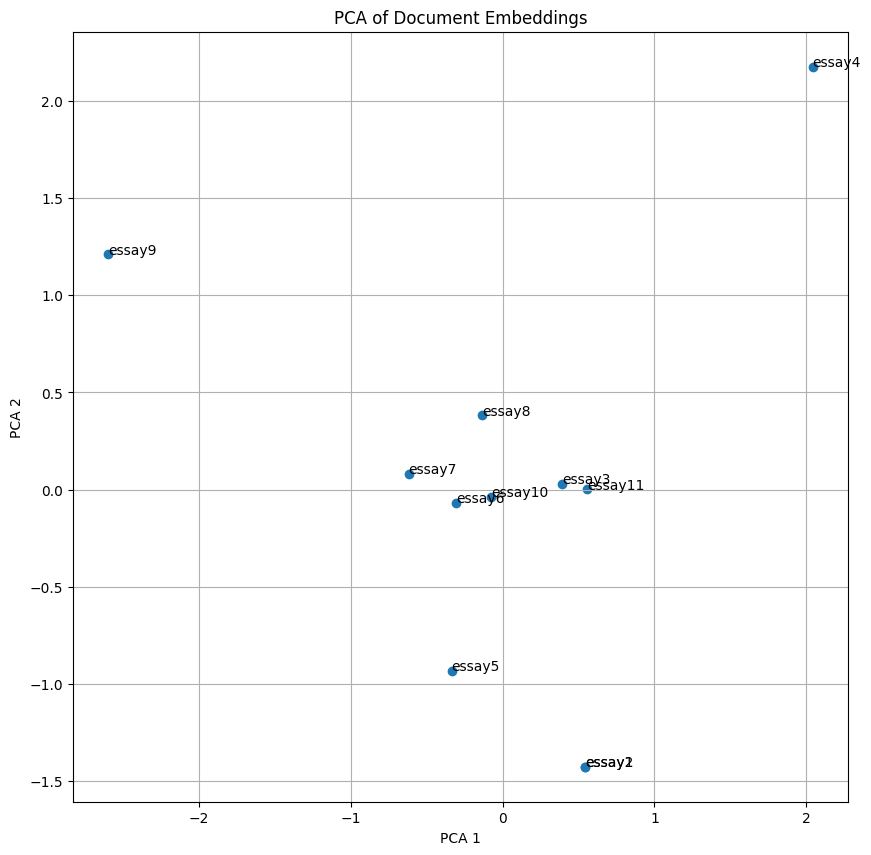

In [37]:
pca, components = get_embedding_pca(embed_matrix, n_components=2)

# plot with matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
plt.scatter(pca[:, 0], pca[:, 1])
for i, name in idxtoname.items():
    plt.annotate(name, (pca[i, 0], pca[i, 1]))
plt.title('PCA of Document Embeddings')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.grid(True)

In [72]:
# # plot t-sne
# from sklearn.manifold import TSNE
# tsne = TSNE(n_components=2, random_state=43, max_iter=2000)
# tsne_results = tsne.fit_transform(embed_matrix)
# plt.figure(figsize=(10, 10))
# plt.scatter(tsne_results[:, 0], tsne_results[:, 1])
# for i, name in idxtoname.items():
#     plt.annotate(name, (tsne_results[i, 0], tsne_results[i, 1]))
# plt.title('t-SNE of Document Embeddings')
# plt.xlabel('t-SNE 1')
# plt.ylabel('t-SNE 2')
# plt.grid(True)
# plt.show()

## Running queries 

In [38]:
# Load the model and tokenizer
model_name = "mlx-community/all-MiniLM-L6-v2-4bit"
model, tokenizer = load(model_name)

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

In [39]:
def embed_text(text): 

    # Tokenize and generate embedding
    input_ids = tokenizer.encode(text, return_tensors="mlx")
    outputs = model(input_ids)
    raw_embeds = outputs.last_hidden_state[:, 0, :] # CLS token
    text_embeds = outputs.text_embeds # mean pooled and normalized embeddings
    return np.array(raw_embeds)

In [40]:
def normalize_embeds(embeds):
    norms = np.linalg.norm(embeds, axis=1, keepdims=True)
    return embeds / norms

def get_inner_prods(query_embeds, norm_embed_matrix, idxtoname, top_k=5):
    query_norm = query_embeds / np.linalg.norm(query_embeds)
    similarities = norm_embed_matrix @ query_norm.T
    top_k_indices = np.argsort(similarities, axis=0)[-top_k:][::-1]
    results = [(idxtoname[i[0]], similarities[i][0]) for i in top_k_indices]
    return results

In [41]:
norm_embed_matrix = normalize_embeds(embed_matrix)

In [42]:
query = "How do I be more happy?"
query_embeds = embed_text(query)
results = get_inner_prods(query_embeds, norm_embed_matrix, idxtoname, top_k=5)
results

[('essay8', array([0.85219837])),
 ('essay2', array([0.83667751])),
 ('essay1', array([0.83667751])),
 ('essay5', array([0.83533281])),
 ('essay3', array([0.83383148]))]

In [43]:
query = "How do I be more sad?"
query_embeds = embed_text(query)
results = get_inner_prods(query_embeds, norm_embed_matrix, idxtoname, top_k=5)
results

[('essay6', array([0.84736179])),
 ('essay8', array([0.8410638])),
 ('essay2', array([0.83418025])),
 ('essay1', array([0.83418025])),
 ('essay5', array([0.82933879]))]

In [44]:
query = "Red Queen's race"
query_embeds = embed_text(query)
results = get_inner_prods(query_embeds, norm_embed_matrix, idxtoname, top_k=5)
results

[('essay7', array([0.77653716])),
 ('essay5', array([0.61923305])),
 ('essay8', array([0.6180122])),
 ('essay3', array([0.61389157])),
 ('essay6', array([0.60577361]))]

## Creating linear transformations from PCA

In [45]:
print(f"Shape of pca: {pca.shape}")
print(f"Shape of norm_embed_matrix: {norm_embed_matrix.shape}")

Shape of pca: (11, 2)
Shape of norm_embed_matrix: (11, 384)


Let's start by making a linear transformation where the null space is the span of pca dim 1. 

 - $d$ = dimension of each embedding
 - $N$ = number of embeddings in `norm_embed_matrix`

Let $v_1 \in \mathbb R^d$ be the normalized PCA dim 1 vector. 

Let $W\in \mathbb R^{N \times d}$ be the normalized embedding matrix for each of the $N$ documents

Since $v_1$ is normalized, we can construct

$$P = v_1 v_1^T \in \mathbb R^{d \times d}$$

and 

$$H=I-\lambda P$$

Then $\lambda \in [0, 1]$ sets the amount by which we "nullify" $\text{span}(v_1)$ in linear transformation $H$, so 

$$H(\lambda=0) v_1 = 0$$
$$H(\lambda=1) v_1 = 1$$

Then we can apply it in the embeddings matrix process by changing

$$W v$$
to 
$$W H v$$

and see what the embeddings look like with a linear transformation 

In [73]:
v1 = components[1]  # First principal component
print("norm of v1: ",np.linalg.norm(v1))
v1 = v1 / np.linalg.norm(v1)  # Normalize v1
print("norm of v1 after normalization: ",np.linalg.norm(v1))

v2 = components[1]


norm of v1:  1.0
norm of v1 after normalization:  1.0


In [74]:
v1_ = v1.reshape(-1, 1)  # Shape (d, 1)
P = v1_ @ v1_.T  # Shape (d, d)
print("Shape of P: ", P.shape)

A = np.eye(P.shape[0]) - P  # Shape (d, d)

print("Shape of A: ", A.shape)

# let's see what the inner product of A @ v1  and v2 is
print("A @ v1: ", np.linalg.norm(A @ v1))  # Should be close to zero
print("A @ v2: ", np.linalg.norm(A @ v2))  # Should be close to 1

Shape of P:  (384, 384)
Shape of A:  (384, 384)
A @ v1:  2.1037942331609533e-16
A @ v2:  2.1037942331609533e-16


In [75]:
# now let's transform the normalized embedding matrix
transformed_embeds = norm_embed_matrix @ A.T  # Shape (N, d)
transformed_embeds = normalize_embeds(transformed_embeds)

# now let's run some queries on the transformed embeds


In [76]:
query = "How do I be more happy?"
query_embeds = embed_text(query)
results = get_inner_prods(query_embeds, transformed_embeds, idxtoname, top_k=5)
results

[('essay8', array([0.85487347])),
 ('essay2', array([0.8535113])),
 ('essay1', array([0.8535113])),
 ('essay5', array([0.840653])),
 ('essay3', array([0.8338531]))]

In [81]:
query = "How do I be more sad?"

print("Transformed matrix: ")
query_embeds = embed_text(query)
results = get_inner_prods(query_embeds, transformed_embeds, idxtoname, top_k=5)
for r in results: 
    print(r)

print("Original matrix: ")
query_embeds = embed_text(query)
results = get_inner_prods(query_embeds, norm_embed_matrix, idxtoname, top_k=5)
for r in results:
    print(r)

Transformed matrix: 
('essay2', array([0.85059692]))
('essay1', array([0.85059692]))
('essay6', array([0.84711649]))
('essay8', array([0.84380846]))
('essay5', array([0.83438046]))
Original matrix: 
('essay6', array([0.84736179]))
('essay8', array([0.8410638]))
('essay2', array([0.83418025]))
('essay1', array([0.83418025]))
('essay5', array([0.82933879]))


## Exercises

 1. Given a query vector $q$ and a document embedding vector $v$, construct a transformation on $W$ so that $W' q$ **maximizes** inner product with $v$
 2. Given a query vector $q$ and a document embedding vector $v$, construct a transformation on $W$ so that $W' q$ **minimizes** inner product with $v$
 3. Given a **set** of query vectors $q_1, q_2, \dots, q_M$ and a **set** of document embedding vector $v_1, v_2, \dots, v_M$, construct a transformation on $W$ so that $W' q_i$ **maximizes** inner product with $v_i$ for each $i=1, 2, \dots, M$
 4. Given a **set** of query vectors $q_1, q_2, \dots, q_M$ and a **set** of document embedding vector $v_1, v_2, \dots, v_M$, construct a transformation on $W$ so that $W' q_i$ **minimizes** inner product with $v_i$ for each $i=1, 2, \dots, M$
 5. Combine (3, 4)
 6. Sculpt your linear transformation of choice by "baking in" desireable associations between ($q_i, v_i$)